# 第4章 一元线性回归

## 4.1 一元线性回归模型

In [1]:
* 数据集grilic.dta包括758位美国年轻男子的教育投资回报率数据，查看此数据集的变量s与lnw的前10个观测值 ：
use data/grilic.dta,clear
list s lnw in 1/10


     +------------+
     |  s     lnw |
     |------------|
  1. | 12     5.9 |
  2. | 16   5.438 |
  3. | 14    5.71 |
  4. | 12   5.481 |
  5. |  9   5.927 |
     |------------|
  6. |  9   4.804 |
  7. | 18   6.512 |
  8. | 15   5.808 |
  9. | 12   5.737 |
 10. | 18   6.382 |
     +------------+


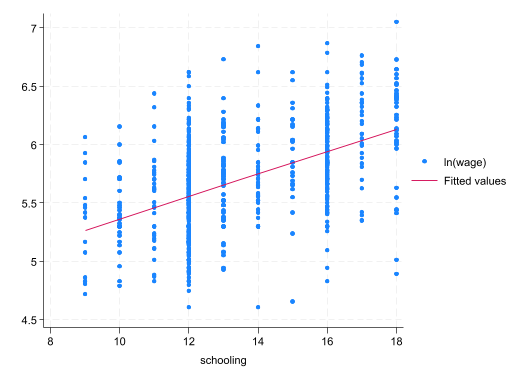

In [2]:
* 为了考察工资对数与教育年限的关系，下面画二者的散点图，并在此图上画出离这些样本点最近的“回归直线”
* “1fit”表示“linear ft”,即线性拟合
twoway scatter lnw s || lfit lnw s

## 4.7 一元线性回归的Stata命令及实例

In [3]:
* 下面使用数据集 grilic.dta,将工资对数(lnw)对教育年限(s)进行一元线性回归。
use data/grilic.dta,clear
reg lnw s


      Source |       SS           df       MS      Number of obs   =       758
-------------+----------------------------------   F(1, 756)       =    255.70
       Model |  35.2039946         1  35.2039946   Prob > F        =    0.0000
    Residual |  104.082155       756  .137674809   R-squared       =    0.2527
-------------+----------------------------------   Adj R-squared   =    0.2518
       Total |   139.28615       757  .183997556   Root MSE        =    .37105

------------------------------------------------------------------------------
         lnw | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           s |   .0966245   .0060425    15.99   0.000     .0847624    .1084866
       _cons |   4.391486   .0821136    53.48   0.000     4.230288    4.552684
------------------------------------------------------------------------------


* “Coefficient”表示回归系数(Coefficient),而“_cons”表示常数项(constant)。
* 上表中左上部显示，TSS(Total)为139.28615,其中可解释部分 ESS(Model)
为35.2039946,而不可解释部分RSS(Residual)为104.082 155。
* 上表中右上部显示，R-squared为0.2527,即教育年限约可解释工资对数25%变动。

In [4]:
* 如果想进行无常数项的回归，可输入如下命令
reg lnw s,noc


      Source |       SS           df       MS      Number of obs   =       758
-------------+----------------------------------   F(1, 757)       =  36727.24
       Model |  24154.3906         1  24154.3906   Prob > F        =    0.0000
    Residual |  497.855977       757  .657669719   R-squared       =    0.9798
-------------+----------------------------------   Adj R-squared   =    0.9798
       Total |  24652.2466       758  32.5227528   Root MSE        =    .81097

------------------------------------------------------------------------------
         lnw | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           s |   .4154001   .0021676   191.64   0.000     .4111449    .4196553
------------------------------------------------------------------------------


* 无常数项回归的$R^2$高达0.9798。但无常数项的$R^2$与有常数项的$R^2$并不可比，而后者更具经济意义。
* 在有常数项的回归中，常数项在1%水平上显著不为0,故此例应包括常数项。

## 4.8 Stata命令运行结果的存储与调用

所有的 Stata命令可以分为两种，即e-类命令(e-class commands)与 r-类命令
(r-class commands)。e-类命令为“估计命令”(estimation commands),比如“regress”;而所有其他命令为r-类命令(r可理解为the rest),比如，“summarize”。

In [5]:
use data/grilic.dta,clear
* r-类命令
sum s


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
           s |        758    13.40501    2.231828          9         18


In [6]:
* r-类命令的运行结果都存储在“r()”中，可以通过输入命令“return list”来显示
return list


scalars:
                  r(N) =  758
              r(sum_w) =  758
               r(mean) =  13.40501319261214
                r(Var) =  4.981058057949899
                 r(sd) =  2.231828411403955
                r(min) =  9
                r(max) =  18
                r(sum) =  10161


In [7]:
* 为了计算“变异系数”(coefficient of variation,即标准差除以平均值),可使用以下命令
display r(sd)/r(mean)

.16649207


In [8]:
* e-类命令
reg lnw s


      Source |       SS           df       MS      Number of obs   =       758
-------------+----------------------------------   F(1, 756)       =    255.70
       Model |  35.2039946         1  35.2039946   Prob > F        =    0.0000
    Residual |  104.082155       756  .137674809   R-squared       =    0.2527
-------------+----------------------------------   Adj R-squared   =    0.2518
       Total |   139.28615       757  .183997556   Root MSE        =    .37105

------------------------------------------------------------------------------
         lnw | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           s |   .0966245   .0060425    15.99   0.000     .0847624    .1084866
       _cons |   4.391486   .0821136    53.48   0.000     4.230288    4.552684
------------------------------------------------------------------------------


In [9]:
* e-类命令的运行结果都存储在“e()”中，可以通过输人命令“ereturn list”来显示
ereturn list


scalars:
                  e(N) =  758
              e(sum_w) =  758
               e(df_m) =  1
               e(df_r) =  756
                  e(F) =  255.7039662336325
                 e(r2) =  .2527458374860051
               e(rmse) =  .3710455612613365
                e(mss) =  35.20399459202193
                e(rss) =  104.0821552499956
               e(r2_a) =  .2517574060541082
                 e(ll) =  -323.0498302841153
               e(ll_0) =  -433.4714451849196
               e(rank) =  2

macros:
            e(cmdline) : "regress lnw s"
              e(title) : "Linear regression"
          e(marginsok) : "XB default"
                e(vce) : "ols"
             e(depvar) : "lnw"
                e(cmd) : "regress"
         e(properties) : "b V"
            e(predict) : "regres_p"
              e(model) : "ols"
          e(estat_cmd) : "regress_estat"

matrices:
                  e(b) :  1 x 2
                  e(V) :  2 x 2
               e(beta) :  1 x 1

functions:
  

## 4.9 总体回归函数与样本回归函数：蒙特卡罗模拟

In [10]:
clear
* 确定随机抽样的样本容量为20
set obs 20
* 指定随机抽样的“种子”为10101
set seed 10101
* 得到服从N(3,4^2)分布的随机样本，记为x
gen x = rnormal(3,4)
* 得到服从N(0,9^2)分布的随机样本，记为e
gen e = rnormal(0,9)
* 计算被解释变量y
gen y = 1 + 2*x + e
* 把y对x进行 OLS回归
reg y x

Number of observations (_N) was 0, now 20.

      Source |       SS           df       MS      Number of obs   =        20
-------------+----------------------------------   F(1, 18)        =     19.92
       Model |  2203.98944         1  2203.98944   Prob > F        =    0.0003
    Residual |  1991.43362        18  110.635201   R-squared       =    0.5253
-------------+----------------------------------   Adj R-squared   =    0.4990
       Total |  4195.42306        19   220.81174   Root MSE        =    10.518

------------------------------------------------------------------------------
           y | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           x |   2.161337   .4842442     4.46   0.000     1.143978    3.178697
       _cons |   .0558832   2.931816     0.02   0.985    -6.103634      6.2154
------------------------------------------------------------------------------


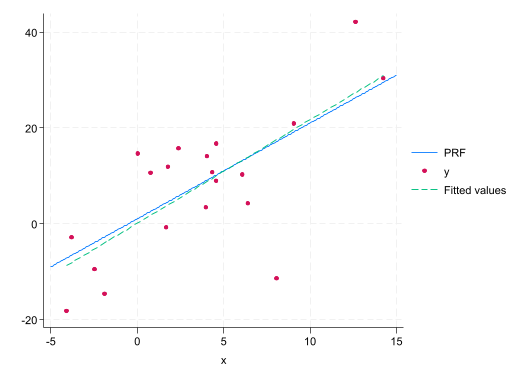

In [11]:
* 把总体回归函数、散点图与样本回归函数画在一起
* 选择项“range(-5 15)”用于指定画图的横轴范围介于-5与15之间；默认为0与1之间
twoway function PRF=1+2*x,range(-5 15) || scatter y x || lfit y x,lp(dash)